In [1]:
# Install if needed (run once)
# !pip install torch scikit-learn matplotlib numpy --quiet

# Core libraries
import numpy as np                              # numerical arrays
import torch                                    # PyTorch — neural net framework
import torch.nn as nn                           # network layers
import torch.optim as optim                     # optimizers (SGD, Adam, AdamW)
import matplotlib.pyplot as plt                 # plotting
from sklearn.datasets import make_classification  # synthetic data generator
from sklearn.model_selection import train_test_split  # data splitting
from sklearn.preprocessing import StandardScaler      # feature scaling
import warnings                                 # silence noise
warnings.filterwarnings("ignore")               # cleaner output
print("Setup complete ✓")                       # confirmation


Setup complete ✓


1. Reproducibility — Pin Everything
Recall from the slides: "A result you can't reproduce isn't a result."

We seed numpy, torch, and Python's RNG so every run produces the same numbers.

In [2]:
def set_seed(seed=42):
    """Make training fully reproducible across libraries."""
    np.random.seed(seed)                        # numpy RNG
    torch.manual_seed(seed)                     # PyTorch CPU RNG
    torch.cuda.manual_seed_all(seed)            # PyTorch GPU RNG (safe even without GPU)
    # Make CuDNN deterministic (slightly slower, but reproducible)
    torch.backends.cudnn.deterministic = True   # force deterministic algorithms
    torch.backends.cudnn.benchmark = False      # disable algorithm auto-tuning
    print(f"Seed set to {seed} ✓")              # confirmation

# Apply the seed
set_seed(42)                                    # call once at the top of every script

Seed set to 42 ✓


2. Synthetic Data — A Tunable Playground
We generate a 2-class classification problem with 20 features, only 10 of which are informative — a realistic mini-version of a tabular ML task.

In [3]:
# Generate a synthetic classification dataset
X, y = make_classification(
    n_samples=2000,                             # total rows
    n_features=20,                              # total feature columns
    n_informative=10,                           # how many are actually useful
    n_redundant=5,                              # linear combos of the informative ones
    n_classes=2,                                # binary classification
    class_sep=1.2,                              # how separable classes are (lower = harder)
    random_state=42                             # seed for reproducibility
)

# Show shapes and class balance
print(f"X shape: {X.shape}")                    # (2000, 20)
print(f"y shape: {y.shape}")                    # (2000,)
print(f"Class balance: {np.bincount(y)}")       # how many per class

X shape: (2000, 20)
y shape: (2000,)
Class balance: [1004  996]


3. Three Splits — Train / Validation / Test
Recall from the slides: "Train fits the weights. Validation tunes & chooses models. Test is touched ONCE."

We also use a stratified split so the class balance is preserved in every split, and fit the scaler on TRAIN only — fitting it on the whole dataset would be data leakage.

In [4]:
# First split: peel off 20% as TEST — touched only at the end
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,                              # 20% test
    stratify=y,                                 # preserve class balance
    random_state=42                             # reproducibility
)

# Second split: from the remaining 80%, take 20% as VALIDATION
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.2,                              # 20% of the remaining 80% = 16% of total
    stratify=y_trainval,                        # preserve class balance again
    random_state=42                             # reproducibility
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")  # check sizes

Train: (1280, 20), Val: (320, 20), Test: (400, 20)


In [5]:
# ⚠️  IMPORTANT: fit the scaler on TRAIN only — never on val/test
scaler = StandardScaler()                       # standardizes to mean 0, std 1
X_train = scaler.fit_transform(X_train)         # learn stats AND transform
X_val   = scaler.transform(X_val)               # only transform (use train stats)
X_test  = scaler.transform(X_test)              # only transform (use train stats)

# Convert numpy arrays → PyTorch tensors (float32 for X, long for y)
X_train_t = torch.FloatTensor(X_train)          # train features
y_train_t = torch.LongTensor(y_train)           # train labels (int for cross-entropy)
X_val_t   = torch.FloatTensor(X_val)            # val features
y_val_t   = torch.LongTensor(y_val)             # val labels
X_test_t  = torch.FloatTensor(X_test)           # test features
y_test_t  = torch.LongTensor(y_test)            # test labels

print("Tensors ready ✓")                        # confirmation

Tensors ready ✓


4. Define a Small Neural Network
A simple feed-forward network: 20 → 64 → 32 → 2. The output is logits (raw scores) — CrossEntropyLoss applies softmax internally.

In [6]:
class SimpleNet(nn.Module):
    """A small fully-connected classifier with optional dropout."""
    def __init__(self, in_dim=20, hidden=64, out_dim=2, dropout=0.0):
        super().__init__()                       # init the nn.Module base class
        # Layer 1: input → hidden
        self.fc1 = nn.Linear(in_dim, hidden)     # learnable W and b
        # Layer 2: hidden → smaller hidden
        self.fc2 = nn.Linear(hidden, hidden // 2)
        # Layer 3 (output): smaller hidden → classes
        self.fc3 = nn.Linear(hidden // 2, out_dim)
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)       # 0.0 = no dropout
        # ReLU activation (cheap, works well)
        self.relu = nn.ReLU()                    # introduces non-linearity

    def forward(self, x):
        """Forward pass: x → logits."""
        x = self.relu(self.fc1(x))               # linear + ReLU
        x = self.dropout(x)                      # randomly zero-out some units (train only)
        x = self.relu(self.fc2(x))               # linear + ReLU
        x = self.dropout(x)                      # dropout again
        x = self.fc3(x)                          # final linear → logits (no activation)
        return x                                 # raw scores

# Quick instantiation test
model = SimpleNet(dropout=0.2)                  # 20% dropout
print(model)                                    # show the architecture


SimpleNet(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)


5. The Training Loop — Forward → Loss → Backward → Step
Recall from the slides: this is the central recipe of all neural-network training.

θ := θ - η · ∇θ L
We write it once, then reuse it everywhere.

In [7]:
def train_one_epoch(model, X, y, optimizer, loss_fn, batch_size=64):
    """Run one full pass over the data and return mean loss + accuracy."""
    model.train()                                # set to TRAIN mode (enables dropout etc.)
    n = X.shape[0]                               # number of training examples
    perm = torch.randperm(n)                     # random shuffle for SGD-style training

    total_loss = 0.0                             # accumulator for loss
    total_correct = 0                            # accumulator for correct preds

    # Iterate over mini-batches
    for i in range(0, n, batch_size):            # step through indices
        idx = perm[i:i + batch_size]             # indices for this batch
        xb, yb = X[idx], y[idx]                  # batch inputs and labels

        # === The four-step training recipe ===
        optimizer.zero_grad()                    # 0. clear old gradients
        logits = model(xb)                       # 1. FORWARD — predict
        loss = loss_fn(logits, yb)               # 2. LOSS — measure error
        loss.backward()                          # 3. BACKWARD — backprop gradients
        optimizer.step()                         # 4. STEP — update weights

        # Track metrics
        total_loss += loss.item() * xb.size(0)   # weighted by batch size
        preds = logits.argmax(dim=1)             # class with highest logit
        total_correct += (preds == yb).sum().item()  # count correct predictions

    # Average over all samples
    return total_loss / n, total_correct / n     # (mean_loss, accuracy)


def evaluate(model, X, y, loss_fn):
    """Compute loss and accuracy without updating weights."""
    model.eval()                                 # set to EVAL mode (disables dropout)
    with torch.no_grad():                        # disable gradient tracking (faster)
        logits = model(X)                        # forward only
        loss = loss_fn(logits, y).item()         # scalar loss
        preds = logits.argmax(dim=1)             # predicted classes
        acc = (preds == y).float().mean().item() # accuracy in [0, 1]
    return loss, acc                             # report both


6. Baseline Run — Cross-Entropy + AdamW
Recall from the slides: "Start with cross-entropy + AdamW for classification ... then refine."

In [8]:
# Reset seed so results match across runs
set_seed(42)                                    # reproducibility

# Fresh model — no dropout yet, just baseline
model = SimpleNet(dropout=0.0)                  # no regularization for the baseline

# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()                 # standard for classification
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)  # no weight decay

# Storage for the learning curves
train_losses, val_losses, train_accs, val_accs = [], [], [], []  # one per epoch

# Train for a fixed number of epochs (we'll add early stopping later)
n_epochs = 50                                   # how many full passes
for epoch in range(n_epochs):                   # loop over epochs
    tr_loss, tr_acc = train_one_epoch(model, X_train_t, y_train_t, optimizer, loss_fn)
    va_loss, va_acc = evaluate(model, X_val_t, y_val_t, loss_fn)

    # Save metrics for plotting
    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc);    val_accs.append(va_acc)

    # Print every 10 epochs to avoid spam
    if (epoch + 1) % 10 == 0:                   # every 10th epoch
        print(f"Epoch {epoch+1:>3} | tr_loss={tr_loss:.4f} acc={tr_acc:.3f} | va_loss={va_loss:.4f} acc={va_acc:.3f}")

print("\nBaseline training done ✓")            # confirmation

Seed set to 42 ✓
Epoch  10 | tr_loss=0.1186 acc=0.969 | va_loss=0.1737 acc=0.966
Epoch  20 | tr_loss=0.0712 acc=0.981 | va_loss=0.1791 acc=0.966
Epoch  30 | tr_loss=0.0454 acc=0.988 | va_loss=0.1936 acc=0.959
Epoch  40 | tr_loss=0.0290 acc=0.993 | va_loss=0.2202 acc=0.959
Epoch  50 | tr_loss=0.0165 acc=0.998 | va_loss=0.2391 acc=0.950

Baseline training done ✓


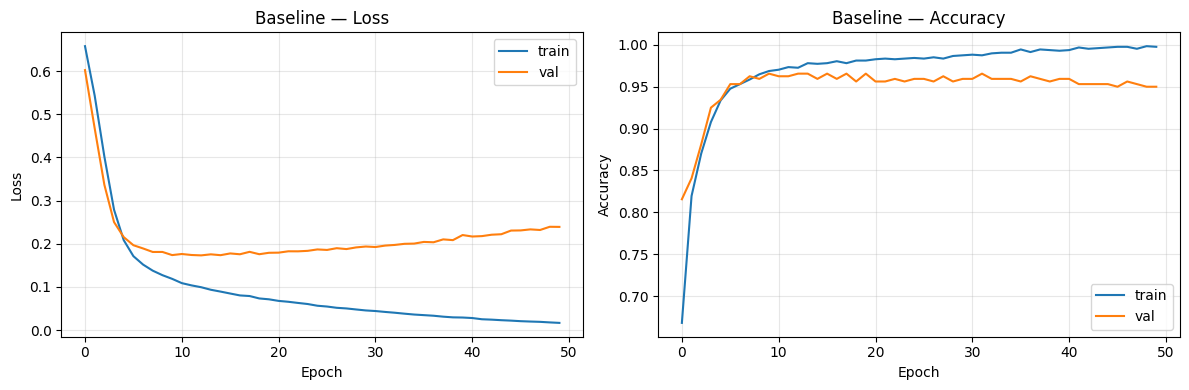

In [9]:
# Plot the baseline learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # two side-by-side plots

# Left plot: loss curves
ax1.plot(train_losses, label="train")           # training loss
ax1.plot(val_losses,   label="val")             # validation loss
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Baseline — Loss")                # title
ax1.legend(); ax1.grid(alpha=0.3)               # legend + grid

# Right plot: accuracy curves
ax2.plot(train_accs, label="train")             # training accuracy
ax2.plot(val_accs,   label="val")               # validation accuracy
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Baseline — Accuracy")            # title
ax2.legend(); ax2.grid(alpha=0.3)               # legend + grid

plt.tight_layout(); plt.show()                  # render

7. Debugging Trick — Overfit a Tiny Batch
Recall from the slides: "If the model can't memorise 10 samples, something is broken."

A healthy model should drive loss → 0 on a 10-sample batch within a few hundred steps. If it can't, the data pipeline, loss, or optimizer is wrong — fix that before full training.

In [10]:
# Take the first 10 training samples
X_tiny = X_train_t[:10]                         # 10 inputs
y_tiny = y_train_t[:10]                         # 10 labels

# Fresh model and optimizer
set_seed(0)                                     # reproducibility for this experiment
tiny_model = SimpleNet(dropout=0.0)             # no regularization — we WANT to overfit
tiny_opt = optim.AdamW(tiny_model.parameters(), lr=1e-2)  # slightly higher LR

# Train repeatedly on these 10 samples
losses_tiny = []                                # log loss per step
for step in range(500):                         # 500 gradient steps
    tiny_opt.zero_grad()                        # clear grads
    logits = tiny_model(X_tiny)                 # forward
    loss = nn.CrossEntropyLoss()(logits, y_tiny)  # loss
    loss.backward()                             # backward
    tiny_opt.step()                             # update
    losses_tiny.append(loss.item())             # log

# Check the final accuracy on these 10 samples
with torch.no_grad():                           # no grad needed
    final_acc = (tiny_model(X_tiny).argmax(1) == y_tiny).float().mean().item()
print(f"Final loss on tiny batch: {losses_tiny[-1]:.6f}")  # should be ~0
print(f"Final accuracy on tiny batch: {final_acc:.2%}")    # should be 100%
# If accuracy < 100%, there's a bug — STOP and investigate

Seed set to 0 ✓
Final loss on tiny batch: 0.000000
Final accuracy on tiny batch: 100.00%


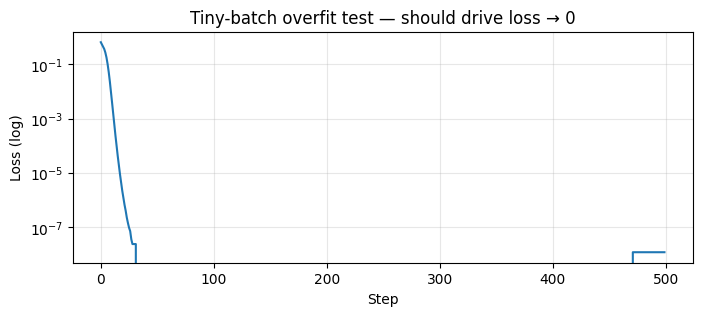

In [11]:
# Plot the tiny-batch loss curve — should hit ~0
plt.figure(figsize=(8, 3))                      # small plot
plt.plot(losses_tiny)                           # loss over training steps
plt.yscale("log")                               # log scale makes the descent visible
plt.xlabel("Step"); plt.ylabel("Loss (log)")    # axis labels
plt.title("Tiny-batch overfit test — should drive loss → 0")
plt.grid(alpha=0.3); plt.show()                 # render

8. The Learning Rate — Run an LR Range Test
Recall from the slides: "If only one hyperparameter is tuned, tune this one."

We train for a few epochs at each of several learning rates and plot the loss vs LR. The sweet spot is the LR with the lowest stable loss — usually about 10× smaller than the one where things blow up.

In [12]:
# Candidate learning rates spanning ~5 orders of magnitude
lrs_to_test = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]  # logarithmically spaced
final_val_losses = []                           # store the result per LR

# Try each LR in turn
for lr in lrs_to_test:                          # one LR at a time
    set_seed(42)                                # reset so the only thing that changes is LR
    m = SimpleNet(dropout=0.0)                  # fresh model each time
    opt = optim.AdamW(m.parameters(), lr=lr)    # only the LR changes
    lf = nn.CrossEntropyLoss()                  # same loss function

    # Train for just a few epochs (enough to see the trend)
    for _ in range(5):                          # quick 5-epoch run
        train_one_epoch(m, X_train_t, y_train_t, opt, lf)

    # Measure validation loss after this short training
    val_loss, _ = evaluate(m, X_val_t, y_val_t, lf)
    final_val_losses.append(val_loss)           # record it
    print(f"LR={lr:>7} → val_loss={val_loss:.4f}")  # show result

Seed set to 42 ✓
LR=  1e-05 → val_loss=0.6998
Seed set to 42 ✓
LR= 0.0001 → val_loss=0.6515
Seed set to 42 ✓
LR=  0.001 → val_loss=0.2154
Seed set to 42 ✓
LR=   0.01 → val_loss=0.1891
Seed set to 42 ✓
LR=    0.1 → val_loss=0.2464
Seed set to 42 ✓
LR=    1.0 → val_loss=0.6246


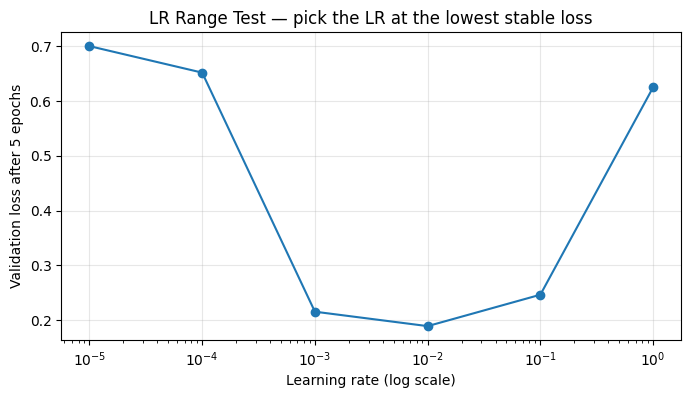


Best LR from range test: 0.01


In [13]:
# Plot val loss vs LR on a log-x axis — the classic 'U' shape
plt.figure(figsize=(8, 4))                      # set size
plt.plot(lrs_to_test, final_val_losses, "o-")   # line + markers
plt.xscale("log")                               # log scale on the x-axis (LR spans orders)
plt.xlabel("Learning rate (log scale)")
plt.ylabel("Validation loss after 5 epochs")
plt.title("LR Range Test — pick the LR at the lowest stable loss")
plt.grid(alpha=0.3); plt.show()                 # render

# Best LR
best_lr = lrs_to_test[int(np.argmin(final_val_losses))]  # min-loss LR
print(f"\nBest LR from range test: {best_lr}")           # report

9. Regularization — Weight Decay & Dropout
Recall from the slides: "Weight decay penalises large weights; dropout makes no neuron indispensable."

We compare three configurations at the same LR and architecture.

In [14]:
def train_run(dropout=0.0, weight_decay=0.0, lr=1e-3, n_epochs=50):
    """Helper: train one config and return the val-accuracy curve."""
    set_seed(42)                                # reproducibility
    m = SimpleNet(dropout=dropout)              # build the model
    opt = optim.AdamW(m.parameters(), lr=lr, weight_decay=weight_decay)
    lf = nn.CrossEntropyLoss()                  # standard loss

    val_acc_history = []                        # log val acc per epoch
    for _ in range(n_epochs):                   # train for n_epochs
        train_one_epoch(m, X_train_t, y_train_t, opt, lf)  # one pass
        _, va_acc = evaluate(m, X_val_t, y_val_t, lf)      # val accuracy
        val_acc_history.append(va_acc)          # record it
    return val_acc_history, m                   # return history and final model


# Three configurations to compare
configs = {
    "No regularization":     dict(dropout=0.0, weight_decay=0.0),     # baseline
    "Weight decay only":     dict(dropout=0.0, weight_decay=1e-2),    # L2 penalty
    "Dropout + weight decay": dict(dropout=0.3, weight_decay=1e-2),   # both
}

# Run each and collect results
results = {}                                    # dict of name → history
for name, cfg in configs.items():               # iterate configs
    print(f"Training: {name} ...")              # progress
    history, _ = train_run(**cfg)               # train this config
    results[name] = history                     # save the curve
print("All configs trained ✓")                  # confirmation


Training: No regularization ...
Seed set to 42 ✓
Training: Weight decay only ...
Seed set to 42 ✓
Training: Dropout + weight decay ...
Seed set to 42 ✓
All configs trained ✓


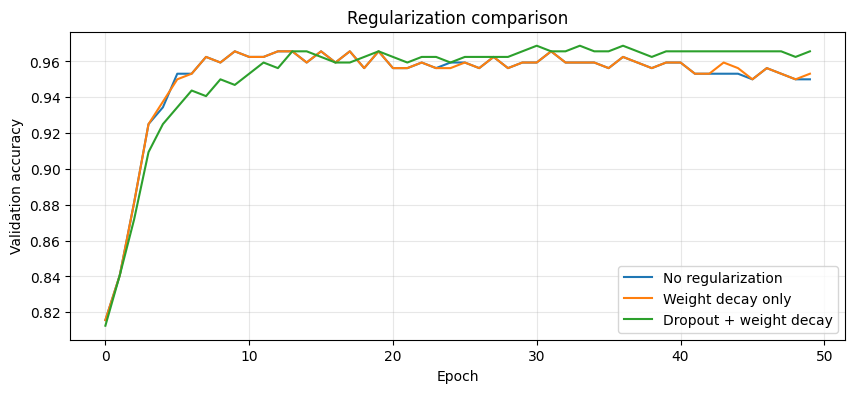


Final validation accuracy:
  No regularization               0.9500
  Weight decay only               0.9531
  Dropout + weight decay          0.9656


In [15]:
# Plot val-accuracy curves for the three configs
plt.figure(figsize=(10, 4))                     # plot size
for name, history in results.items():           # one line per config
    plt.plot(history, label=name)               # add to plot
plt.xlabel("Epoch"); plt.ylabel("Validation accuracy")
plt.title("Regularization comparison")          # title
plt.legend(); plt.grid(alpha=0.3); plt.show()   # show legend + grid + render

# Print final val accuracies for easy comparison
print("\nFinal validation accuracy:")
for name, history in results.items():           # tabulate
    print(f"  {name:<30}  {history[-1]:.4f}")   # last-epoch accuracy

10. Early Stopping + Best Checkpoint
Recall from the slides: "Watch validation loss; stop when it stops improving (with patience), and keep the best checkpoint — not the last."

The pattern:

Track the best val loss seen so far.
If val loss doesn't improve for patience epochs → stop.
Restore the weights from the best epoch, not the last.

In [17]:
def train_with_early_stopping(dropout=0.3, weight_decay=1e-2,
                              lr=1e-3, n_epochs=200, patience=10):
    """Train until val-loss stops improving for `patience` consecutive epochs."""
    set_seed(42)                                 # reproducibility
    m = SimpleNet(dropout=dropout)               # build model
    opt = optim.AdamW(m.parameters(), lr=lr, weight_decay=weight_decay)
    lf = nn.CrossEntropyLoss()                   # loss

    # State tracking for early stopping
    best_val_loss = float("inf")                 # best seen so far (init high)
    best_epoch = -1                              # which epoch was best
    best_state = None                            # parameters at best epoch
    epochs_no_improve = 0                        # patience counter

    history = {"train_loss": [], "val_loss": [], "val_acc": []}  # logs

    # Loop with potential early exit
    for epoch in range(n_epochs):                # max epochs
        tr_loss, _ = train_one_epoch(m, X_train_t, y_train_t, opt, lf)
        va_loss, va_acc = evaluate(m, X_val_t, y_val_t, lf)

        # Log metrics
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        # Did we improve?
        if va_loss < best_val_loss - 1e-4:       # strict improvement (with small tolerance)
            best_val_loss = va_loss              # update best
            best_epoch = epoch                   # remember when
            # Save a deep copy of the weights
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
            epochs_no_improve = 0                # reset patience counter
        else:                                    # no improvement
            epochs_no_improve += 1                # tick patience

        # Stop if we've waited too long
        if epochs_no_improve >= patience:        # patience exceeded
            print(f"⏹  Early stop at epoch {epoch+1} (best was epoch {best_epoch+1})")
            break                                # exit the training loop

    # Restore the BEST weights — not the last
    if best_state is not None:                   # safety check
        m.load_state_dict(best_state)            # rewind to best epoch

    return m, history, best_epoch                # return model + logs + best epoch

# Run it
final_model, history, best_epoch = train_with_early_stopping()
print(f"Best epoch: {best_epoch+1}, best val loss: {min(history['val_loss']):.4f}")




Seed set to 42 ✓
⏹  Early stop at epoch 37 (best was epoch 27)
Best epoch: 27, best val loss: 0.1662


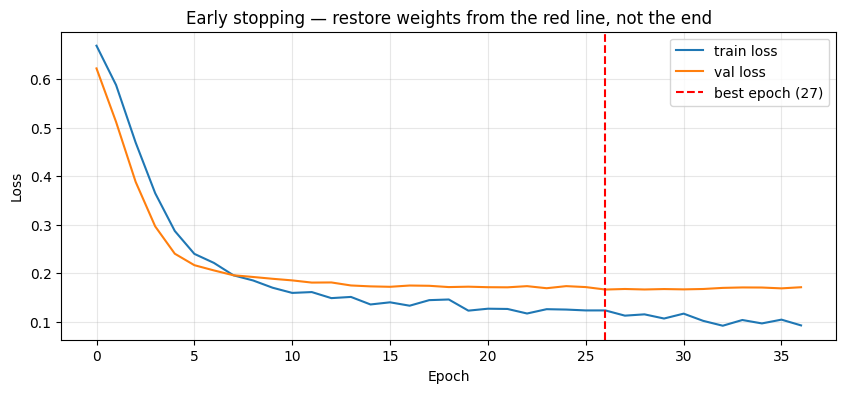

In [18]:
# Plot the val loss with the best-epoch marker
plt.figure(figsize=(10, 4))                     # size
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"],   label="val loss")
plt.axvline(best_epoch, color="red", linestyle="--", label=f"best epoch ({best_epoch+1})")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Early stopping — restore weights from the red line, not the end")
plt.legend(); plt.grid(alpha=0.3); plt.show()   # render

11. Final Evaluation — Touch the Test Set Once
Recall from the slides: "Test — touched ONCE, final estimate."

We've made every modeling decision (architecture, LR, regularization, stopping criterion) on the validation set. Now — only now — do we look at test performance.

In [19]:
# Final evaluation on the held-out test set
test_loss, test_acc = evaluate(final_model, X_test_t, y_test_t, nn.CrossEntropyLoss())
print(f"Final TEST loss:     {test_loss:.4f}")  # held-out loss
print(f"Final TEST accuracy: {test_acc:.4f}")   # held-out accuracy

# Save the best model to disk — production deployable artifact
torch.save(final_model.state_dict(), "best_model.pt")  # save weights only
print("\nModel saved to best_model.pt ✓")             # confirmation

Final TEST loss:     0.1792
Final TEST accuracy: 0.9525

Model saved to best_model.pt ✓
